PHẦN 1: IMPORT THƯ VIỆN & ĐỌC DỮ LIỆU

In [1]:
# 1.1 IMPORT THƯ VIỆN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120

print("Import thư viện thành công!")

Matplotlib is building the font cache; this may take a moment.


Import thư viện thành công!


In [2]:
# 1.2 ĐỌC DỮ LIỆU
df = pd.read_csv('credit_risk_dataset.csv')

print(f"\n Kích thước dataset: {df.shape[0]:,} dòng × {df.shape[1]} cột")


 Kích thước dataset: 32,581 dòng × 12 cột


In [3]:
# 1.3 XEM DỮ LIỆU MẪU
print("\n 5 dòng đầu tiên:")
print(df.head())

print("\n 5 dòng cuối:")
print(df.tail())


 5 dòng đầu tiên:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT             123.00   
1          21           9600                   OWN               5.00   
2          25           9600              MORTGAGE               1.00   
3          23          65500                  RENT               4.00   
4          24          54400                  RENT               8.00   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y            

In [4]:
# 1.4 THÔNG TIN TỔNG QUAN
print("\n Thông tin dataset:")
print(df.info())


 Thông tin dataset:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB
None


In [5]:
# 1.5 KIỂU DỮ LIỆU TỪNG CỘT
print("\n Kiểu dữ liệu:")
dtype_df = pd.DataFrame({
    'Cột': df.columns,
    'Kiểu dữ liệu': df.dtypes.values,
    'Số giá trị null': df.isnull().sum().values,
    'Tỷ lệ null (%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'Số giá trị unique': df.nunique().values
})
print(dtype_df.to_string(index=False))


 Kiểu dữ liệu:
                       Cột Kiểu dữ liệu  Số giá trị null  Tỷ lệ null (%)  Số giá trị unique
                person_age        int64                0            0.00                 58
             person_income        int64                0            0.00               4295
     person_home_ownership          str                0            0.00                  4
         person_emp_length      float64              895            2.75                 36
               loan_intent          str                0            0.00                  6
                loan_grade          str                0            0.00                  7
                 loan_amnt        int64                0            0.00                753
             loan_int_rate      float64             3116            9.56                348
               loan_status        int64                0            0.00                  2
       loan_percent_income      float64                0        

In [6]:
# 1.6 THỐNG KÊ MÔ TẢ
print("\n Thống kê mô tả (biến số):")
print(df.describe())

print("\n Thống kê mô tả (biến phân loại):")
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for col in cat_cols:
    print(f"\n  [{col}] – {df[col].nunique()} giá trị unique:")
    print(df[col].value_counts().to_string())


 Thống kê mô tả (biến số):
       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
count    32581.00       32581.00           31686.00   32581.00       29465.00   
mean        27.73       66074.85               4.79    9589.37          11.01   
std          6.35       61983.12               4.14    6322.09           3.24   
min         20.00        4000.00               0.00     500.00           5.42   
25%         23.00       38500.00               2.00    5000.00           7.90   
50%         26.00       55000.00               4.00    8000.00          10.99   
75%         30.00       79200.00               7.00   12200.00          13.47   
max        144.00     6000000.00             123.00   35000.00          23.22   

       loan_status  loan_percent_income  cb_person_cred_hist_length  
count     32581.00             32581.00                    32581.00  
mean          0.22                 0.17                        5.80  
std           0.41              

In [7]:
# 1.7 PHÂN PHỐI BIẾN MỤC TIÊU
print("\n Phân phối biến mục tiêu (loan_status):")
target = df['loan_status'].value_counts()
target_pct = df['loan_status'].value_counts(normalize=True) * 100
print(f"  0 – Không vỡ nợ : {target[0]:,} ({target_pct[0]:.1f}%)")
print(f"  1 – Vỡ nợ       : {target[1]:,} ({target_pct[1]:.1f}%)")
print(f"  → Mất cân bằng nhẹ: tỷ lệ 78.2% / 21.8%")


 Phân phối biến mục tiêu (loan_status):
  0 – Không vỡ nợ : 25,473 (78.2%)
  1 – Vỡ nợ       : 7,108 (21.8%)
  → Mất cân bằng nhẹ: tỷ lệ 78.2% / 21.8%


In [8]:
# 1.8 MÔ TẢ Ý NGHĨA CÁC CỘT
print("\nMô tả ý nghĩa các cột:")
col_desc = {
    'person_age':                   'Tuổi của người vay',
    'person_income':                'Thu nhập hàng năm (USD)',
    'person_home_ownership':        'Tình trạng nhà ở (RENT/OWN/MORTGAGE/OTHER)',
    'person_emp_length':            'Số năm đi làm',
    'loan_intent':                  'Mục đích vay (PERSONAL/EDUCATION/MEDICAL/...)',
    'loan_grade':                   'Hạng tín dụng (A=tốt nhất → G=xấu nhất)',
    'loan_amnt':                    'Số tiền vay (USD)',
    'loan_int_rate':                'Lãi suất vay (%)',
    'loan_status':                  'Biến mục tiêu: 0=Không vỡ nợ, 1=Vỡ nợ',
    'loan_percent_income':          'Tỷ lệ tiền vay / thu nhập',
    'cb_person_default_on_file':    'Lịch sử vỡ nợ trước đây (Y/N)',
    'cb_person_cred_hist_length':   'Số năm lịch sử tín dụng',
}
for col, desc in col_desc.items():
    print(f"  {col:<35} → {desc}")


Mô tả ý nghĩa các cột:
  person_age                          → Tuổi của người vay
  person_income                       → Thu nhập hàng năm (USD)
  person_home_ownership               → Tình trạng nhà ở (RENT/OWN/MORTGAGE/OTHER)
  person_emp_length                   → Số năm đi làm
  loan_intent                         → Mục đích vay (PERSONAL/EDUCATION/MEDICAL/...)
  loan_grade                          → Hạng tín dụng (A=tốt nhất → G=xấu nhất)
  loan_amnt                           → Số tiền vay (USD)
  loan_int_rate                       → Lãi suất vay (%)
  loan_status                         → Biến mục tiêu: 0=Không vỡ nợ, 1=Vỡ nợ
  loan_percent_income                 → Tỷ lệ tiền vay / thu nhập
  cb_person_default_on_file           → Lịch sử vỡ nợ trước đây (Y/N)
  cb_person_cred_hist_length          → Số năm lịch sử tín dụng


PHẦN 2: KHÁM PHÁ DỮ LIỆU (EDA)

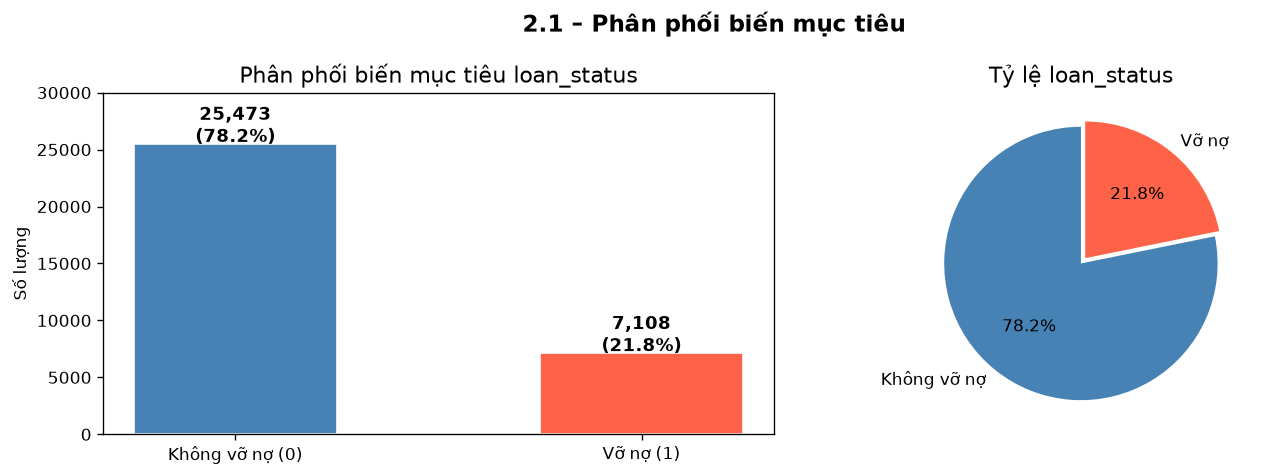

In [9]:
# 2.1 PHÂN PHỐI BIẾN MỤC TIÊU
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ cột
counts = df['loan_status'].value_counts()
axes[0].bar(['Không vỡ nợ (0)', 'Vỡ nợ (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Phân phối biến mục tiêu loan_status', fontsize=13)
axes[0].set_ylabel('Số lượng')
axes[0].set_ylim(0, 30000)

# Biểu đồ tròn
axes[1].pie(counts.values, labels=['Không vỡ nợ', 'Vỡ nợ'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Tỷ lệ loan_status', fontsize=13)

plt.suptitle('2.1 – Phân phối biến mục tiêu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', dpi=150)
plt.show()


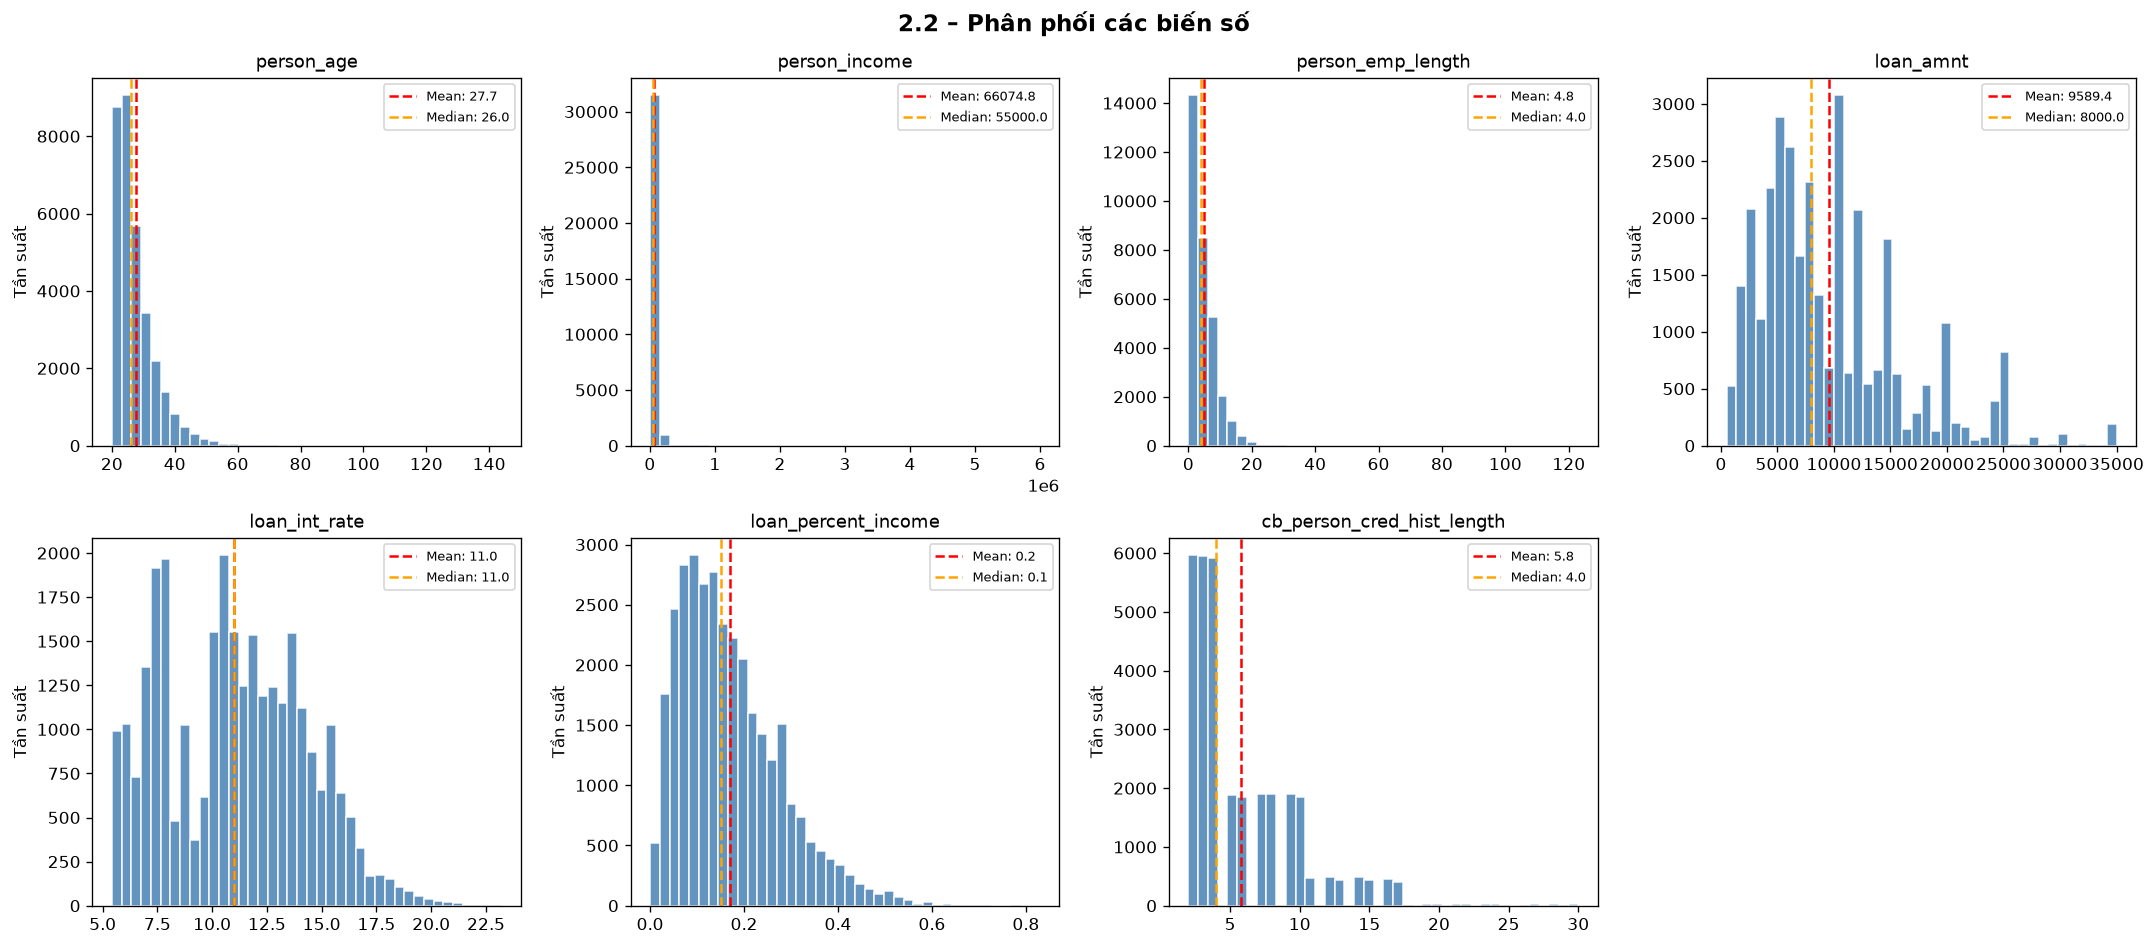

In [10]:
# 2.2 PHÂN PHỐI CÁC BIẾN SỐ
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40,
                 color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--',
                    linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Tần suất')

axes[-1].axis('off')  # ô thừa
plt.suptitle('2.2 – Phân phối các biến số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_numeric_distributions.png', dpi=150)
plt.show()

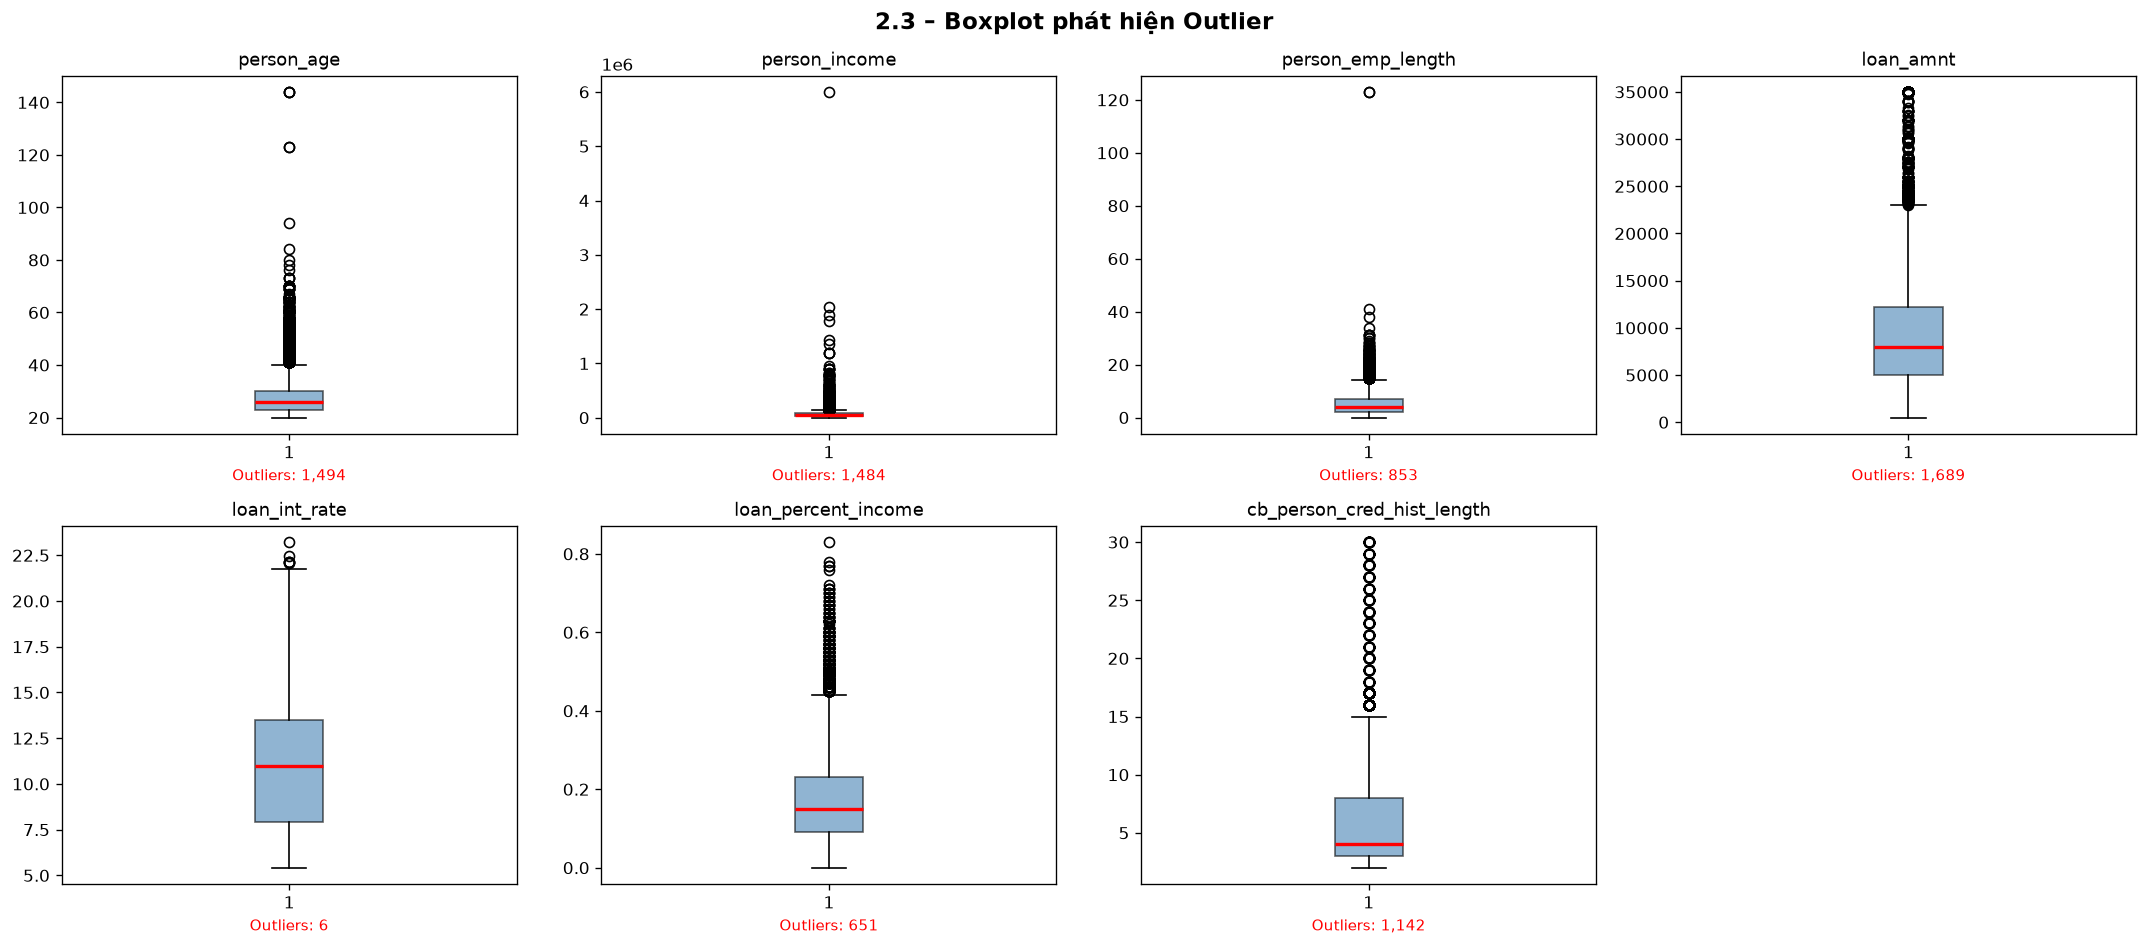

In [11]:
# 2.3 BOXPLOT – PHÁT HIỆN OUTLIER
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    axes[i].set_xlabel(f'Outliers: {outliers:,}', fontsize=9, color='red')

axes[-1].axis('off')
plt.suptitle('2.3 – Boxplot phát hiện Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_boxplots.png', dpi=150)
plt.show()

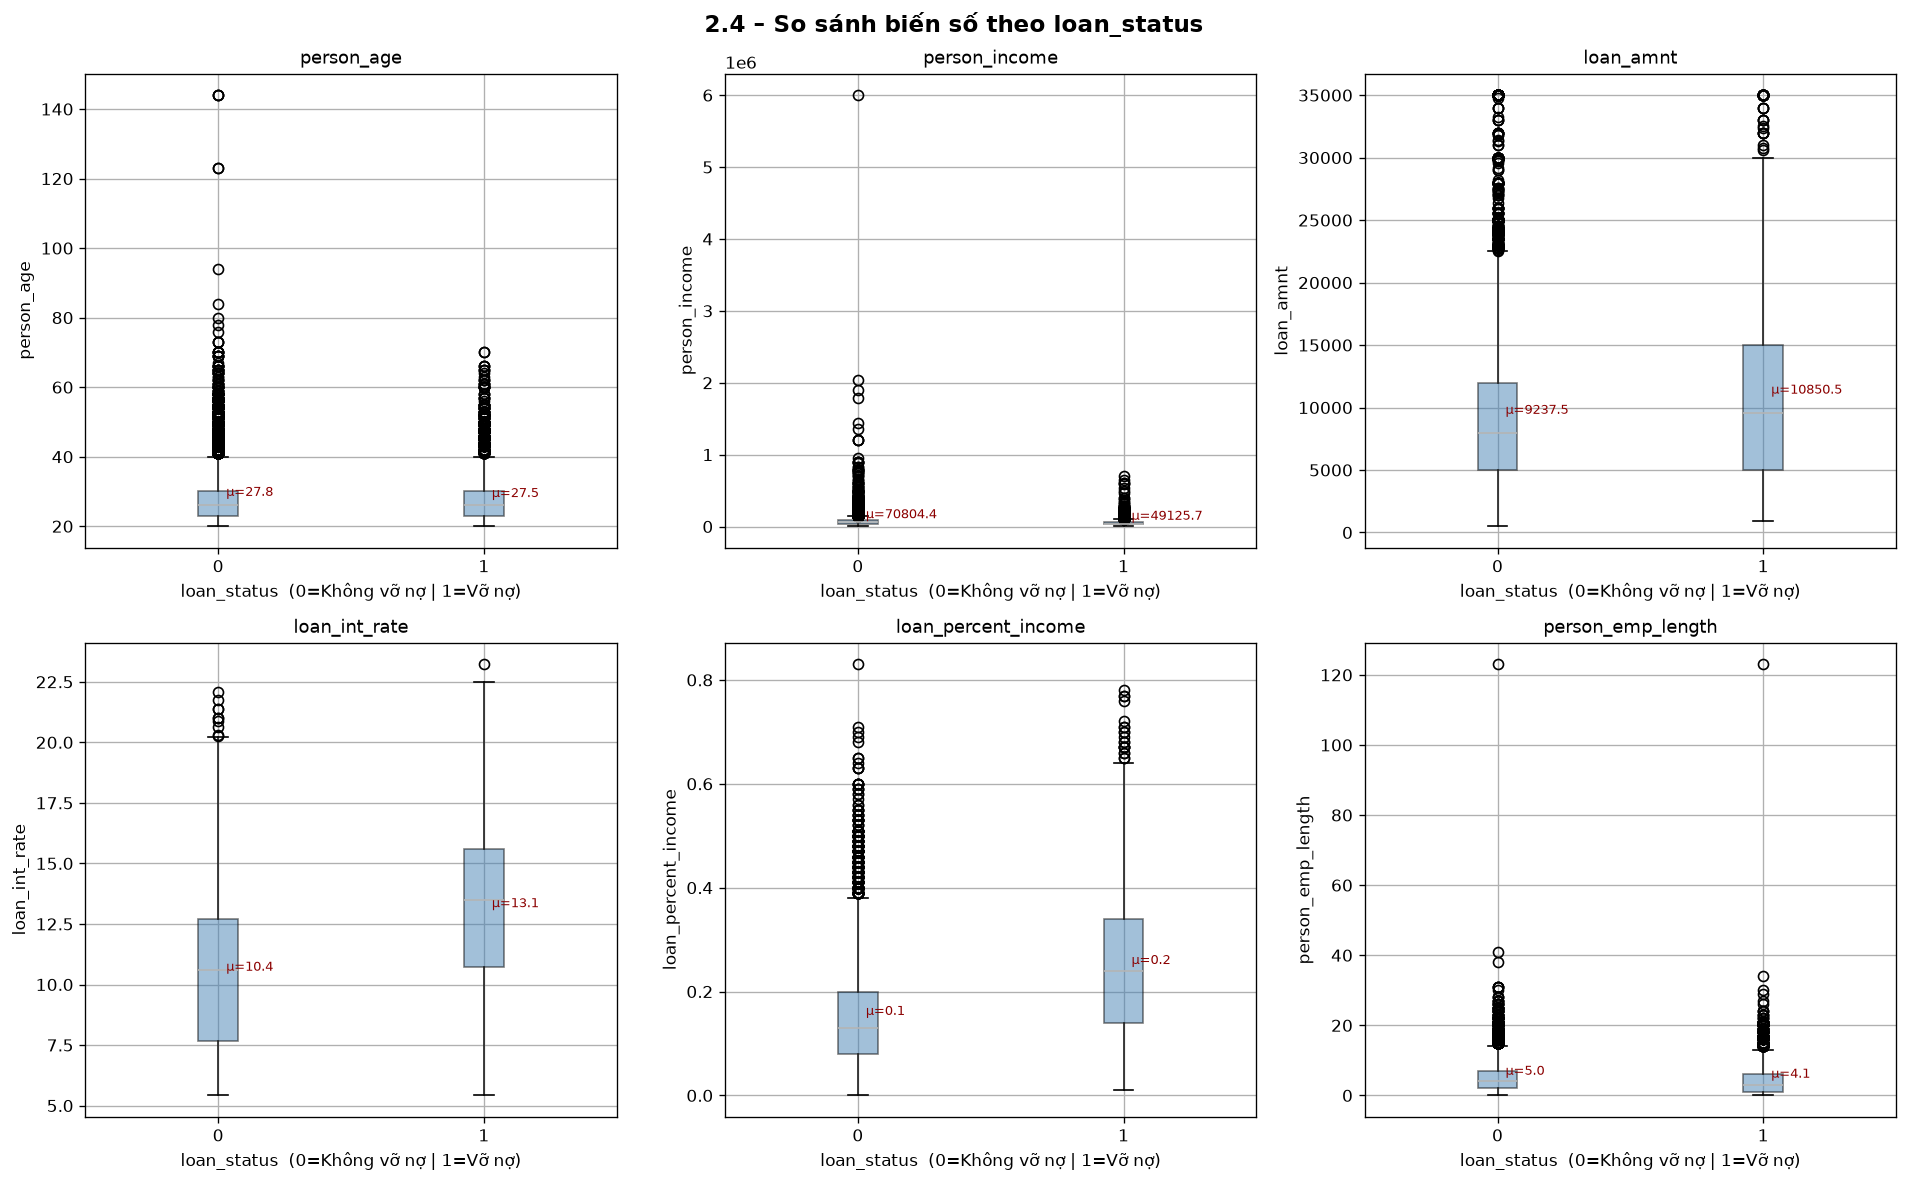

In [12]:
# 2.4 PHÂN TÍCH BIẾN SỐ THEO LOAN_STATUS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cols = ['person_age', 'person_income', 'loan_amnt',
             'loan_int_rate', 'loan_percent_income', 'person_emp_length']

for i, col in enumerate(plot_cols):
    df.boxplot(column=col, by='loan_status', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('loan_status  (0=Không vỡ nợ | 1=Vỡ nợ)')
    axes[i].set_ylabel(col)

    # Ghi mean lên biểu đồ
    for j, status in enumerate([0, 1]):
        mean_val = df[df['loan_status'] == status][col].mean()
        axes[i].text(j + 1, mean_val, f'  μ={mean_val:.1f}',
                     fontsize=8, color='darkred', va='bottom')

plt.suptitle('2.4 – So sánh biến số theo loan_status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_numeric_by_target.png', dpi=150)
plt.show()

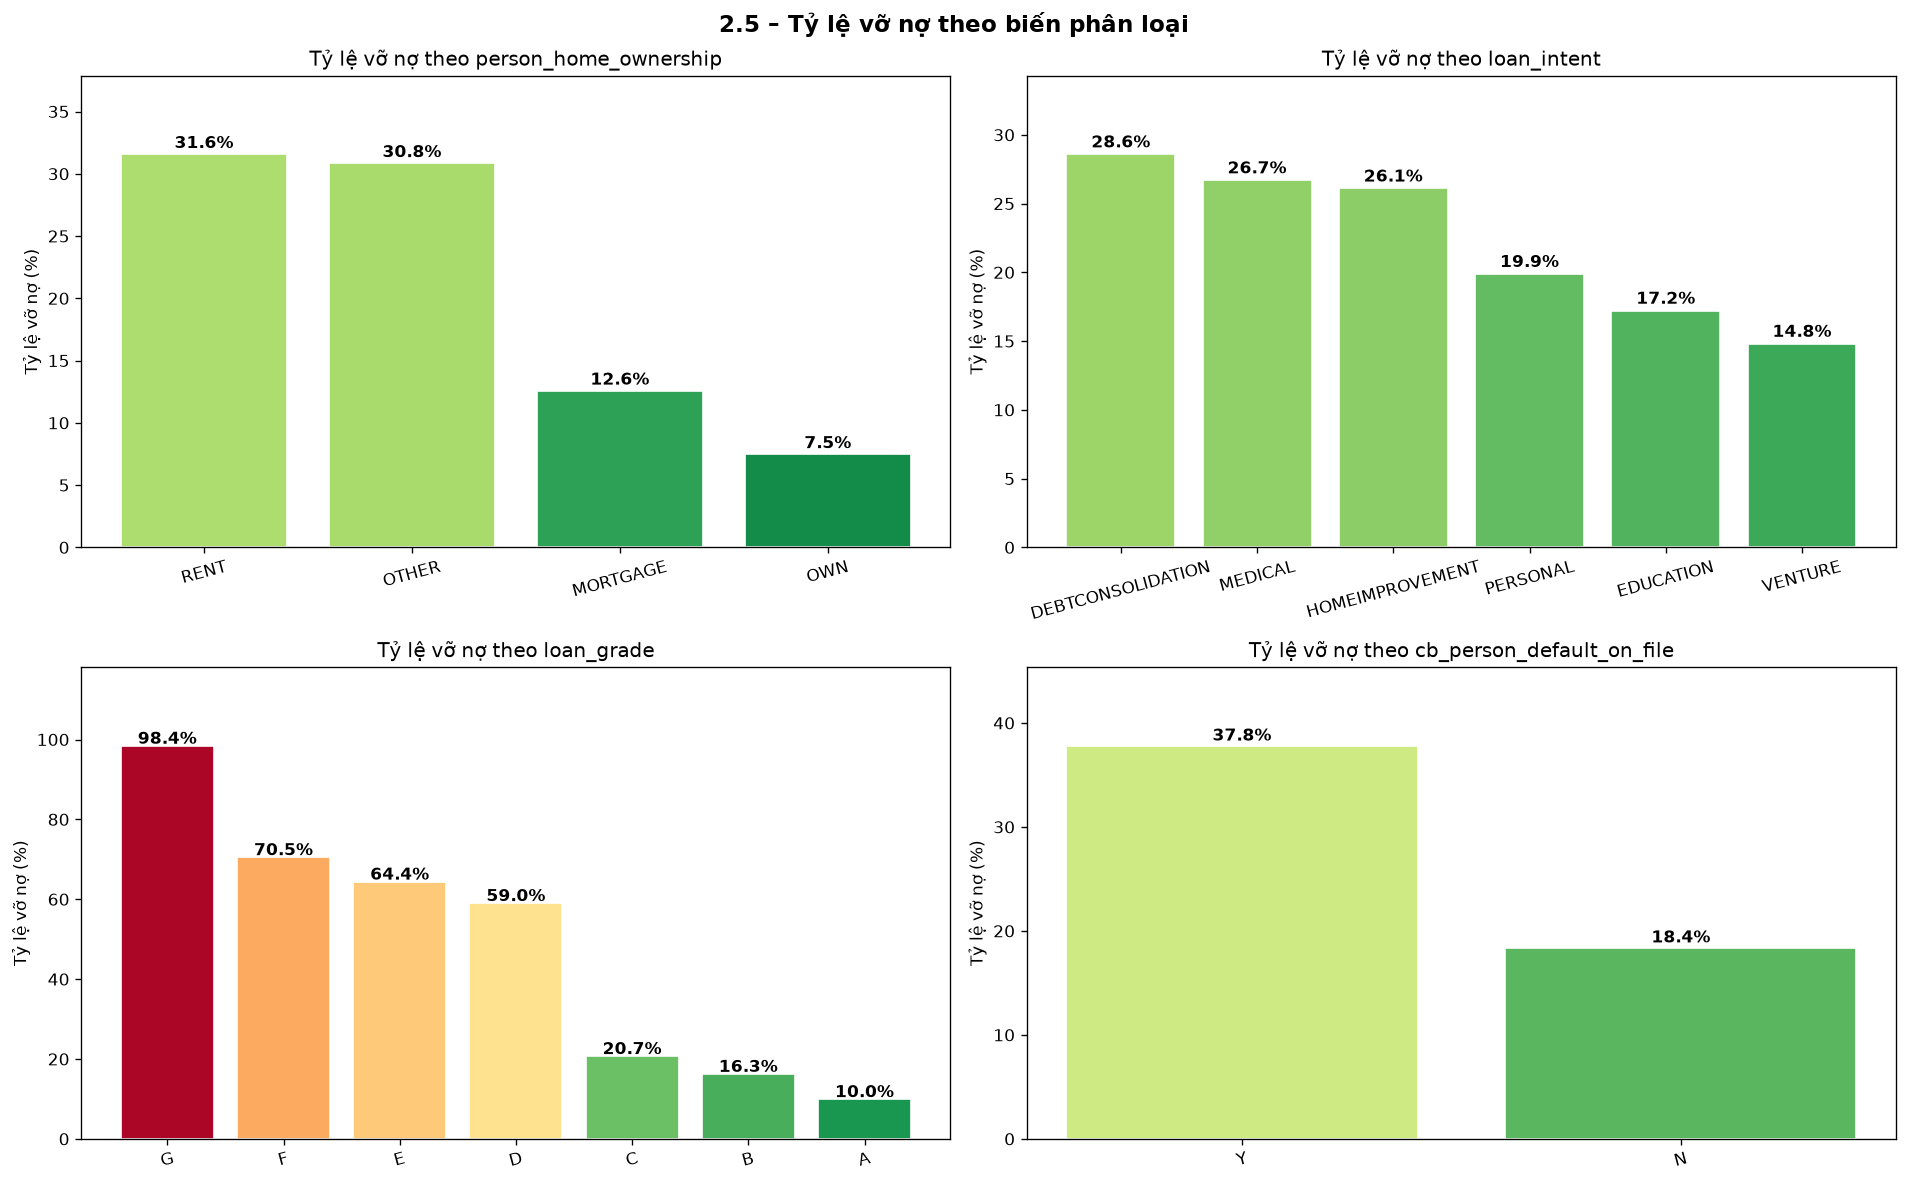

In [13]:
# 2.5 PHÂN TÍCH BIẾN PHÂN LOẠI THEO LOAN_STATUS
cat_cols = ['person_home_ownership', 'loan_intent',
            'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(ct.index, ct.values,
                       color=plt.cm.RdYlGn_r(ct.values / 100),
                       edgecolor='white')
    for bar, val in zip(bars, ct.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(f'Tỷ lệ vỡ nợ theo {col}', fontsize=12)
    axes[i].set_ylabel('Tỷ lệ vỡ nợ (%)')
    axes[i].set_ylim(0, max(ct.values) * 1.2)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('2.5 – Tỷ lệ vỡ nợ theo biến phân loại', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_categorical_by_target.png', dpi=150)
plt.show()

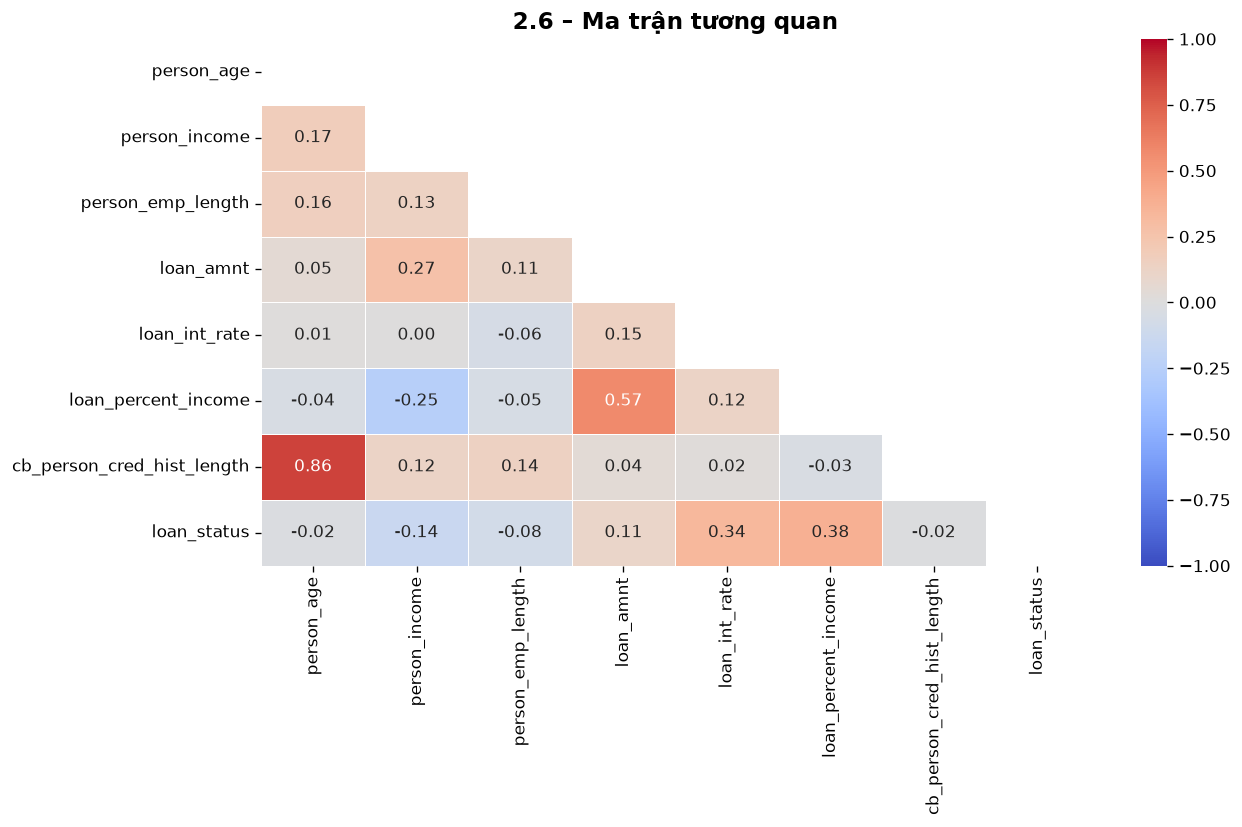

In [14]:
# 2.6 MA TRẬN TƯƠNG QUAN
plt.figure(figsize=(11, 7))
corr = df[num_cols + ['loan_status']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # che tam giác trên
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 10})
plt.title('2.6 – Ma trận tương quan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_correlation_heatmap.png', dpi=150)
plt.show()

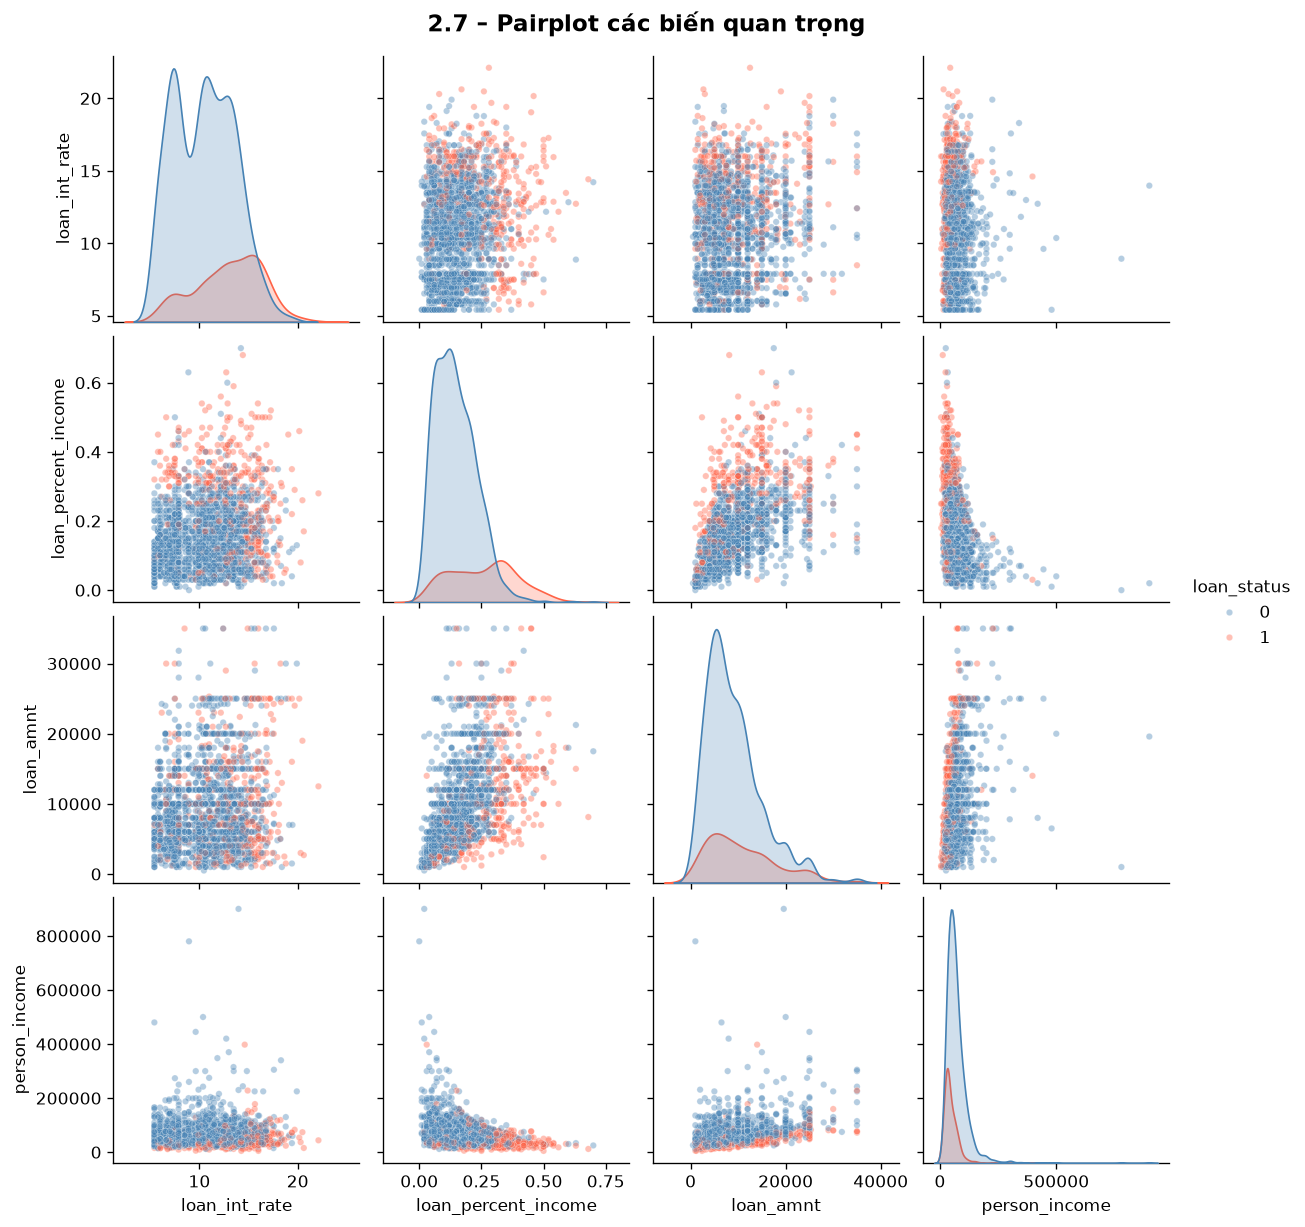

In [15]:
# 2.7 PAIRPLOT CÁC BIẾN QUAN TRỌNG
key_cols = ['loan_int_rate', 'loan_percent_income',
            'loan_amnt', 'person_income', 'loan_status']
sample = df[key_cols].dropna().sample(2000, random_state=42)
g = sns.pairplot(sample, hue='loan_status',
                 palette={0: 'steelblue', 1: 'tomato'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('2.7 – Pairplot các biến quan trọng', y=1.02,
               fontsize=14, fontweight='bold')
plt.savefig('eda_07_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

2.8 TÓM TẮT PHÁT HIỆN TỪ EDA

Biến mục tiêu:
Không vỡ nợ: 78.2%  |  Vỡ nợ: 21.8% → Mất cân bằng nhẹ

Biến số quan trọng:
- loan_int_rate: người vỡ nợ có lãi suất cao hơn
  • loan_percent_income: người vỡ nợ vay nhiều hơn/thu nhập (0.25 vs 0.15)
  • person_income: người vỡ nợ thu nhập thấp hơn ($49K vs $70K)

- Biến phân loại quan trọng:
  • loan_grade G: tỷ lệ vỡ nợ 98.4% (cao nhất)           
  • loan_grade A: tỷ lệ vỡ nợ 10.0% (thấp nhất)          
  • RENT/OTHER: tỷ lệ vỡ nợ ~31% (cao hơn OWN: 7.5%)     

- Outlier cần xử lý:                                      
  • person_age: max=144 (cần lọc > 80)                     
  • person_emp_length: max=123 năm (cần lọc > 60)        
  • person_income: một số giá trị > $1M                   


PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)

In [16]:
# 3.1 SAO CHÉP DỮ LIỆU GỐC
df_clean = df.copy()
print(f"Shape ban đầu: {df_clean.shape}")


Shape ban đầu: (32581, 12)



Outlier phát hiện:
  person_age > 80       : 7 dòng
  person_emp_length > 60: 2 dòng
  person_income > 1M    : 9 dòng

Sau khi lọc outlier: (31676, 12)


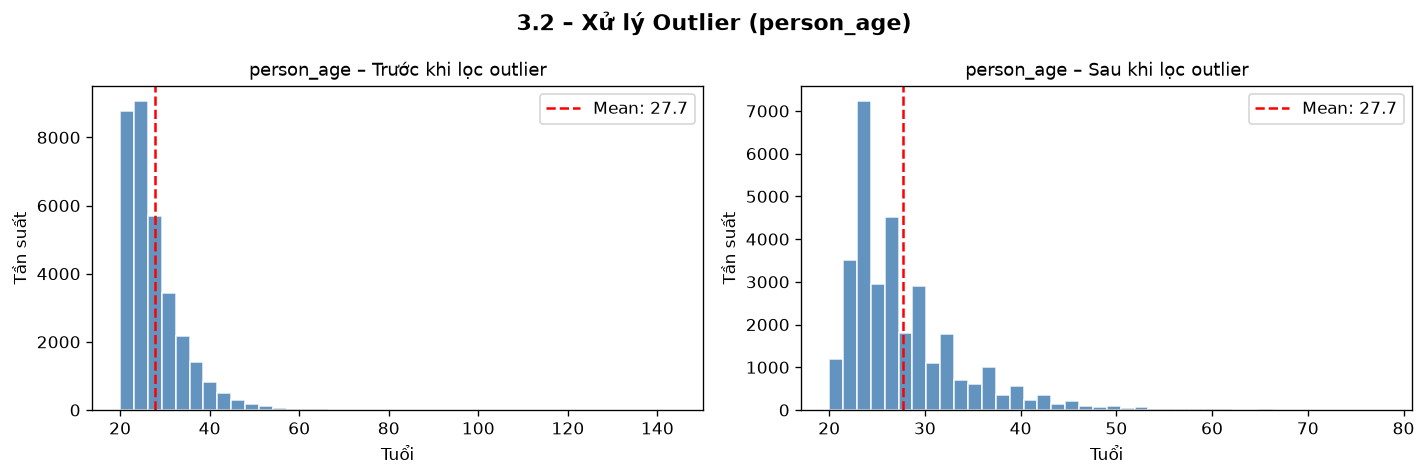

In [17]:
# 3.2 XỬ LÝ OUTLIER
print("\nOutlier phát hiện:")
print(f"  person_age > 80       : {(df_clean['person_age'] > 80).sum()} dòng")
print(f"  person_emp_length > 60: {(df_clean['person_emp_length'] > 60).sum()} dòng")
print(f"  person_income > 1M    : {(df_clean['person_income'] > 1_000_000).sum()} dòng")

# Lọc outlier
df_clean = df_clean[df_clean['person_age'] < 80]
df_clean = df_clean[df_clean['person_emp_length'] < 60]
df_clean = df_clean.reset_index(drop=True)

print(f"\nSau khi lọc outlier: {df_clean.shape}")

# Trực quan hóa trước/sau lọc outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(
    axes,
    [df, df_clean],
    ['Trước khi lọc outlier', 'Sau khi lọc outlier']
):
    ax.hist(data['person_age'], bins=40,
            color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'person_age – {title}', fontsize=11)
    ax.set_xlabel('Tuổi')
    ax.set_ylabel('Tần suất')
    ax.axvline(data['person_age'].mean(), color='red',
               linestyle='--', label=f"Mean: {data['person_age'].mean():.1f}")
    ax.legend()

plt.suptitle('3.2 – Xử lý Outlier (person_age)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pre_01_outlier.png', dpi=150)
plt.show()


 Missing values trước xử lý:
               Số null  Tỷ lệ (%)
loan_int_rate     3046       9.62

 Điền loan_int_rate    bằng median = 10.99
Điền person_emp_length bằng median = 4.00

 Missing values sau xử lý: 0 (còn lại)


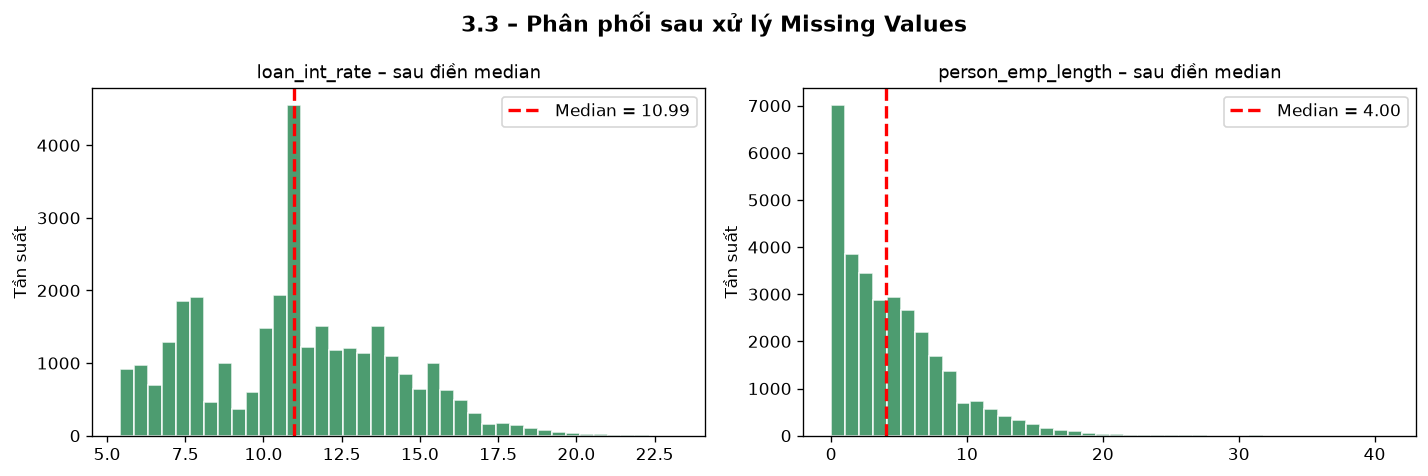

In [18]:
# 3.3 XỬ LÝ MISSING VALUES
print("\n Missing values trước xử lý:")
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({'Số null': missing, 'Tỷ lệ (%)': missing_pct})
print(missing_df[missing_df['Số null'] > 0])

# Điền median (robust với outlier còn lại)
median_int_rate   = df_clean['loan_int_rate'].median()
median_emp_length = df_clean['person_emp_length'].median()

df_clean['loan_int_rate']    = df_clean['loan_int_rate'].fillna(median_int_rate)
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(median_emp_length)

print(f"\n Điền loan_int_rate    bằng median = {median_int_rate:.2f}")
print(f"Điền person_emp_length bằng median = {median_emp_length:.2f}")
print(f"\n Missing values sau xử lý: {df_clean.isnull().sum().sum()} (còn lại)")

# Trực quan hóa missing values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cols_with_missing = ['loan_int_rate', 'person_emp_length']
for ax, col in zip(axes, cols_with_missing):
    ax.hist(df_clean[col], bins=40,
            color='seagreen', edgecolor='white', alpha=0.85)
    ax.axvline(df_clean[col].median(), color='red', linestyle='--',
               linewidth=2, label=f'Median = {df_clean[col].median():.2f}')
    ax.set_title(f'{col} – sau điền median', fontsize=11)
    ax.set_ylabel('Tần suất')
    ax.legend()

plt.suptitle('3.3 – Phân phối sau xử lý Missing Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pre_02_missing.png', dpi=150)
plt.show()


 Encoding biến phân loại:

  [person_home_ownership]
    MORTGAGE                  → 0
    OTHER                     → 1
    OWN                       → 2
    RENT                      → 3

  [loan_intent]
    DEBTCONSOLIDATION         → 0
    EDUCATION                 → 1
    HOMEIMPROVEMENT           → 2
    MEDICAL                   → 3
    PERSONAL                  → 4
    VENTURE                   → 5

  [loan_grade]
    A                         → 0
    B                         → 1
    C                         → 2
    D                         → 3
    E                         → 4
    F                         → 5
    G                         → 6

  [cb_person_default_on_file]
    N                         → 0
    Y                         → 1


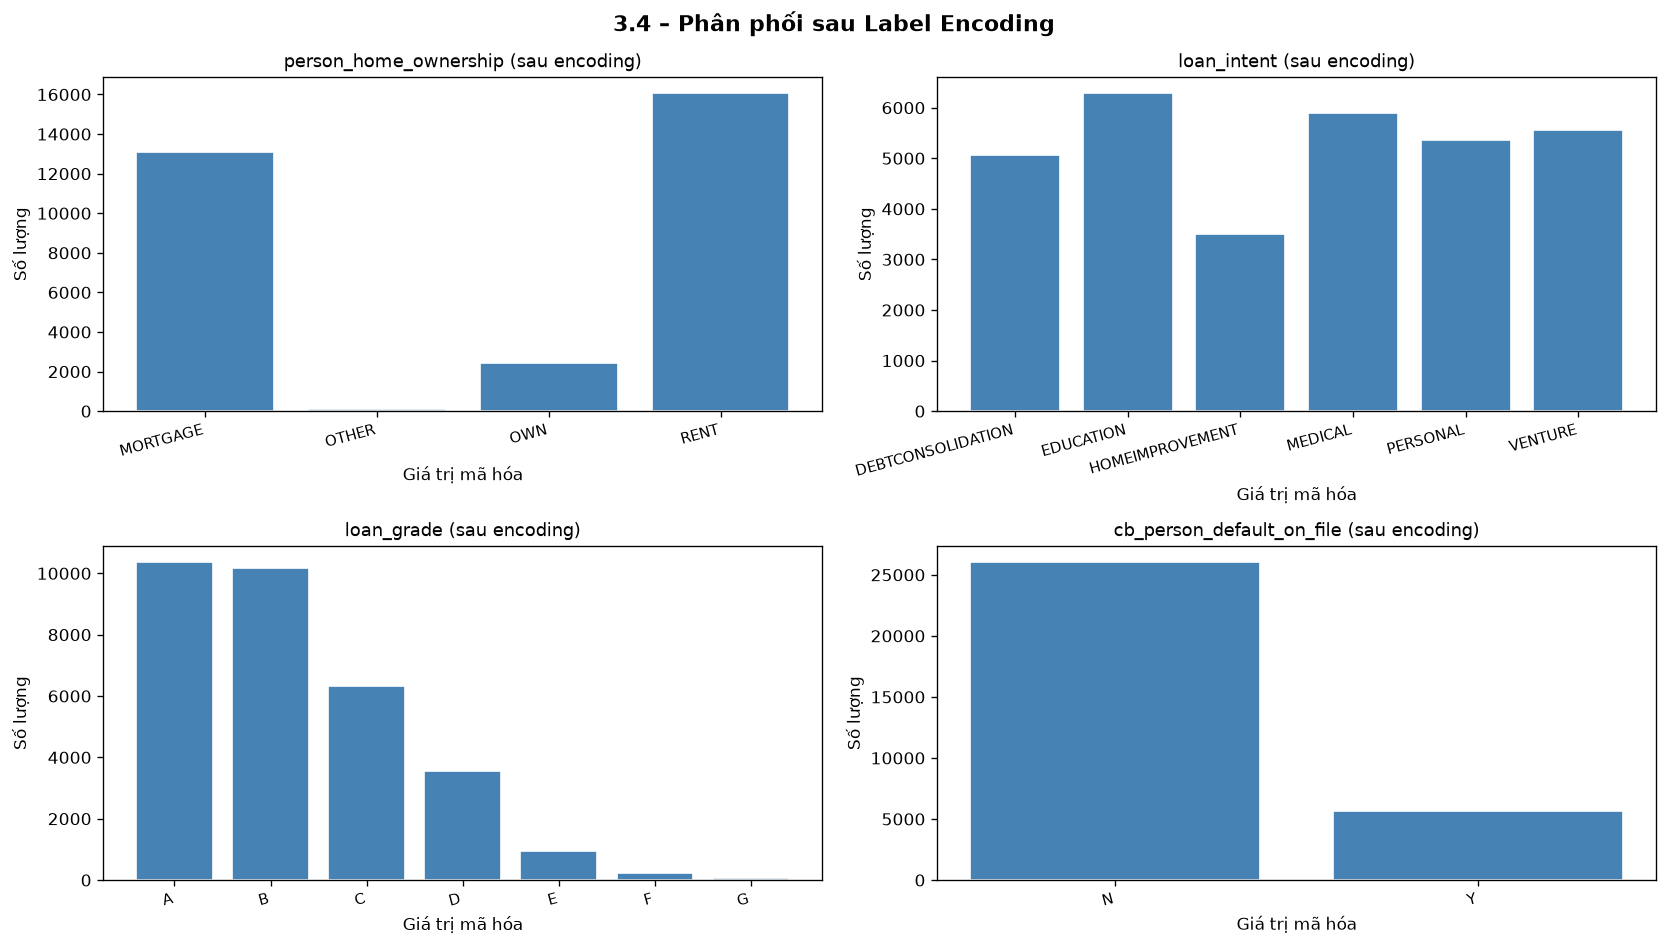

In [19]:
# 3.4 ENCODING BIẾN PHÂN LOẠI
cat_cols = ['person_home_ownership', 'loan_intent',
            'loan_grade', 'cb_person_default_on_file']

print("\n Encoding biến phân loại:")
le = LabelEncoder()
encoding_map = {}

for col in cat_cols:
    original = df_clean[col].unique().tolist()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoded  = sorted(df_clean[col].unique().tolist())
    encoding_map[col] = dict(zip(sorted(original), encoded))
    print(f"\n  [{col}]")
    for k, v in encoding_map[col].items():
        print(f"    {k:25s} → {v}")

# Trực quan hóa encoding
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_clean[col].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values,
                color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} (sau encoding)', fontsize=11)
    axes[i].set_xlabel('Giá trị mã hóa')
    axes[i].set_ylabel('Số lượng')
    # Ghi nhãn gốc
    original_labels = list(encoding_map[col].keys())
    axes[i].set_xticks(counts.index)
    axes[i].set_xticklabels(original_labels, rotation=15, ha='right', fontsize=9)

plt.suptitle('3.4 – Phân phối sau Label Encoding', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pre_03_encoding.png', dpi=150)
plt.show()

In [20]:
# 3.5 CHIA TRAIN / TEST
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n  Chia dữ liệu (stratify=True):")
print(f"  Train : {X_train.shape[0]:,} dòng ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test  : {X_test.shape[0]:,} dòng ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Tỷ lệ loan_status trong Train:")
print((y_train.value_counts(normalize=True)*100).round(1))
print(f"\n  Tỷ lệ loan_status trong Test:")
print((y_test.value_counts(normalize=True)*100).round(1))


  Chia dữ liệu (stratify=True):
  Train : 25,340 dòng (80%)
  Test  : 6,336 dòng (20%)

  Tỷ lệ loan_status trong Train:
loan_status
0   78.50
1   21.50
Name: proportion, dtype: float64

  Tỷ lệ loan_status trong Test:
loan_status
0   78.50
1   21.50
Name: proportion, dtype: float64


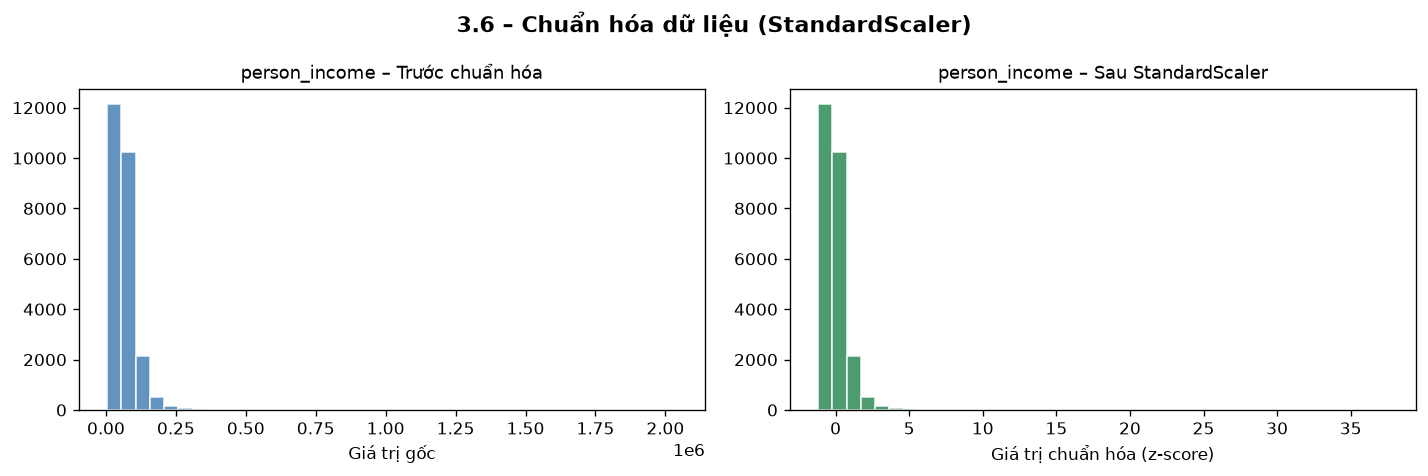

In [21]:
# 3.6 CHUẨN HÓA DỮ LIỆU (STANDARDSCALER)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Trực quan hóa trước/sau scale
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
col_idx = list(X.columns).index('person_income')

axes[0].hist(X_train.iloc[:, col_idx], bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('person_income – Trước chuẩn hóa', fontsize=11)
axes[0].set_xlabel('Giá trị gốc')

axes[1].hist(X_train_scaled[:, col_idx], bins=40,
             color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('person_income – Sau StandardScaler', fontsize=11)
axes[1].set_xlabel('Giá trị chuẩn hóa (z-score)')

plt.suptitle('3.6 – Chuẩn hóa dữ liệu (StandardScaler)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pre_04_scaling.png', dpi=150)
plt.show()

In [22]:
# 3.7 KIỂM TRA DATASET SAU TIỀN XỬ LÝ
print("""
           TỔNG KẾT TIỀN XỬ LÝ DỮ LIỆU
──────────────────────────────────────────────────────────
Bước                        Kết quả
─────────────────────────── ──────────────────────────────
Shape ban đầu               (32.581, 12)
Sau lọc outlier             (31.676, 12)  → bỏ 905 dòng
Missing loan_int_rate       Điền median = 10.99
Missing person_emp_length   Điền median = 4.0
Encoding (4 cột)            Label Encoding
Chia tập                    80% train / 20% test
Chuẩn hóa                   StandardScaler (z-score)
X_train shape               (25.340, 11)
X_test shape                (6.336, 11)
""")

print("Tiền xử lý hoàn tất! Sẵn sàng cho bước xây dựng mô hình.")
print(f"\n Biến đã có:")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"  y_train        : {y_train.shape}")
print(f"  y_test         : {y_test.shape}")


           TỔNG KẾT TIỀN XỬ LÝ DỮ LIỆU
──────────────────────────────────────────────────────────
Bước                        Kết quả
─────────────────────────── ──────────────────────────────
Shape ban đầu               (32.581, 12)
Sau lọc outlier             (31.676, 12)  → bỏ 905 dòng
Missing loan_int_rate       Điền median = 10.99
Missing person_emp_length   Điền median = 4.0
Encoding (4 cột)            Label Encoding
Chia tập                    80% train / 20% test
Chuẩn hóa                   StandardScaler (z-score)
X_train shape               (25.340, 11)
X_test shape                (6.336, 11)

Tiền xử lý hoàn tất! Sẵn sàng cho bước xây dựng mô hình.

 Biến đã có:
  X_train_scaled : (25340, 11)
  X_test_scaled  : (6336, 11)
  y_train        : (25340,)
  y_test         : (6336,)


PHẦN 4: XÂY DỰNG & ĐÁNH GIÁ MÔ HÌNH ENSEMBLE LEARNING

In [23]:
# 4.1 XÂY DỰNG 3 MÔ HÌNH
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
}

print(" Bắt đầu huấn luyện mô hình...\n")
results = {}

for name, model in models.items():
    print(f"   Đang huấn luyện {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob)
    }
    print(f"   {name} – Accuracy: {results[name]['accuracy']:.4f} "
          f"| F1: {results[name]['f1']:.4f} "
          f"| ROC-AUC: {results[name]['roc_auc']:.4f}\n")


 Bắt đầu huấn luyện mô hình...

   Đang huấn luyện Random Forest...
   Random Forest – Accuracy: 0.9324 | F1: 0.8174 | ROC-AUC: 0.9277

   Đang huấn luyện XGBoost...
   XGBoost – Accuracy: 0.9408 | F1: 0.8441 | ROC-AUC: 0.9504

   Đang huấn luyện Gradient Boosting...
   Gradient Boosting – Accuracy: 0.9383 | F1: 0.8384 | ROC-AUC: 0.9491



In [24]:
# 4.2 CLASSIFICATION REPORT CHI TIẾT
print("=" * 60)
for name, v in results.items():
    print(f"\n Classification Report – {name}")
    print("-" * 60)
    print(classification_report(
        y_test, v['y_pred'],
        target_names=['Không vỡ nợ (0)', 'Vỡ nợ (1)']
    ))



 Classification Report – Random Forest
------------------------------------------------------------
                 precision    recall  f1-score   support

Không vỡ nợ (0)       0.92      1.00      0.96      4971
      Vỡ nợ (1)       0.98      0.70      0.82      1365

       accuracy                           0.93      6336
      macro avg       0.95      0.85      0.89      6336
   weighted avg       0.94      0.93      0.93      6336


 Classification Report – XGBoost
------------------------------------------------------------
                 precision    recall  f1-score   support

Không vỡ nợ (0)       0.93      0.99      0.96      4971
      Vỡ nợ (1)       0.98      0.74      0.84      1365

       accuracy                           0.94      6336
      macro avg       0.95      0.87      0.90      6336
   weighted avg       0.94      0.94      0.94      6336


 Classification Report – Gradient Boosting
------------------------------------------------------------
         


 Bảng so sánh hiệu suất:
                   Accuracy  F1-Score  ROC-AUC
Random Forest          0.93      0.82     0.93
XGBoost                0.94      0.84     0.95
Gradient Boosting      0.94      0.84     0.95

🏆 Mô hình tốt nhất (ROC-AUC): XGBoost


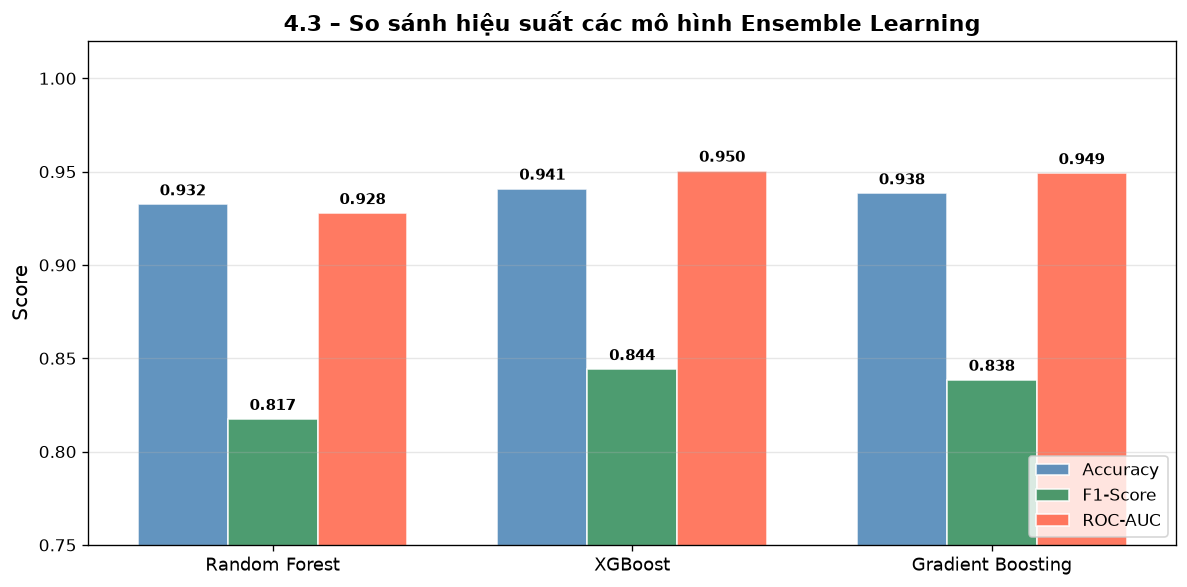

In [25]:
# 4.3 BẢNG SO SÁNH MÔ HÌNH
results_df = pd.DataFrame({
    name: {
        'Accuracy': v['accuracy'],
        'F1-Score': v['f1'],
        'ROC-AUC':  v['roc_auc']
    } for name, v in results.items()
}).T.round(4)

print("\n Bảng so sánh hiệu suất:")
print(results_df.to_string())

best_model_name = results_df['ROC-AUC'].idxmax()
print(f"\n🏆 Mô hình tốt nhất (ROC-AUC): {best_model_name}")

# Biểu đồ so sánh
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df.index))
width = 0.25
colors = ['steelblue', 'seagreen', 'tomato']
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric],
                  width=width, label=metric,
                  color=color, edgecolor='white', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('4.3 – So sánh hiệu suất các mô hình Ensemble Learning',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_01_comparison.png', dpi=150)
plt.show()

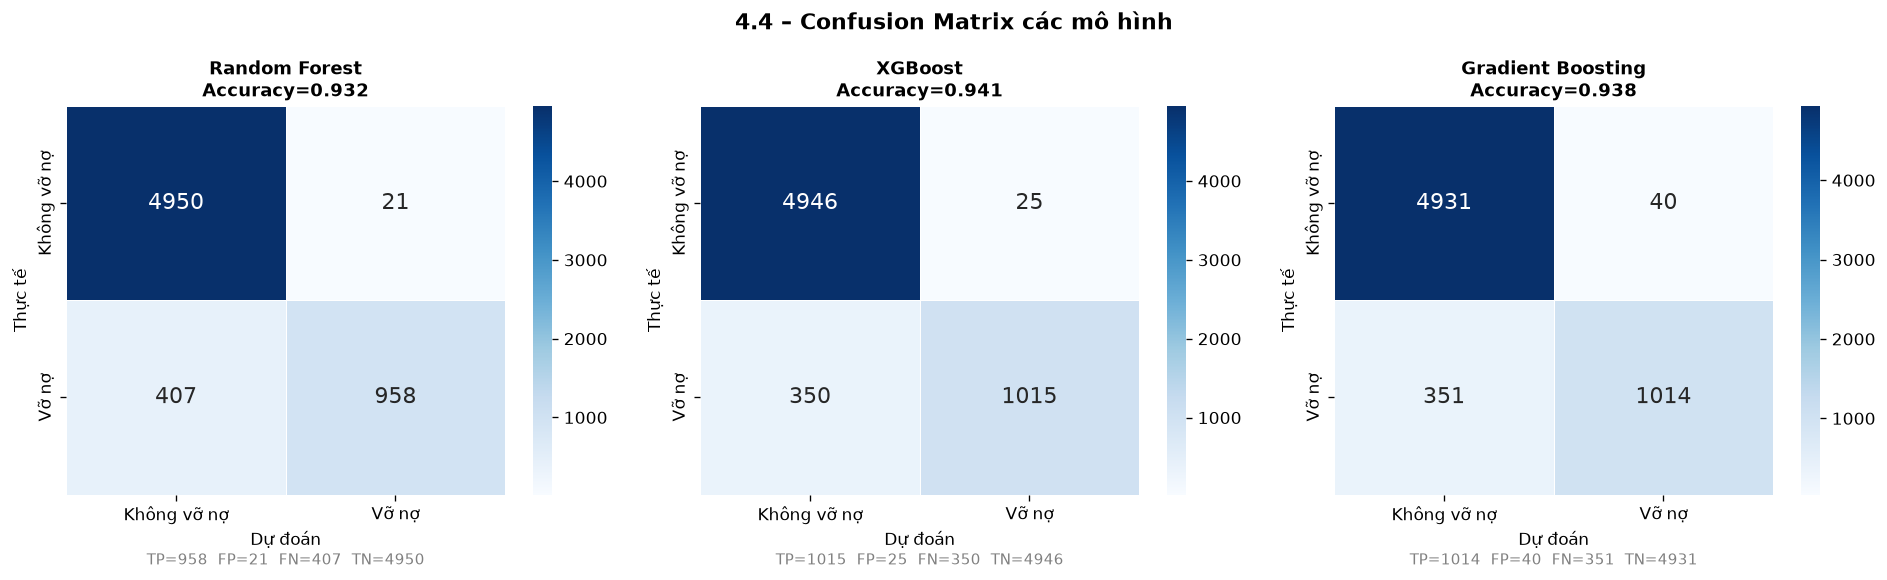

In [26]:
# 4.4 CONFUSION MATRIX
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Không vỡ nợ', 'Vỡ nợ'],
                yticklabels=['Không vỡ nợ', 'Vỡ nợ'],
                annot_kws={'size': 13})
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nAccuracy={v["accuracy"]:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Dự đoán', fontsize=10)
    ax.set_ylabel('Thực tế', fontsize=10)
    ax.text(0.5, -0.18,
            f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
            ha='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.suptitle('4.4 – Confusion Matrix các mô hình', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_02_confusion_matrix.png', dpi=150)
plt.show()


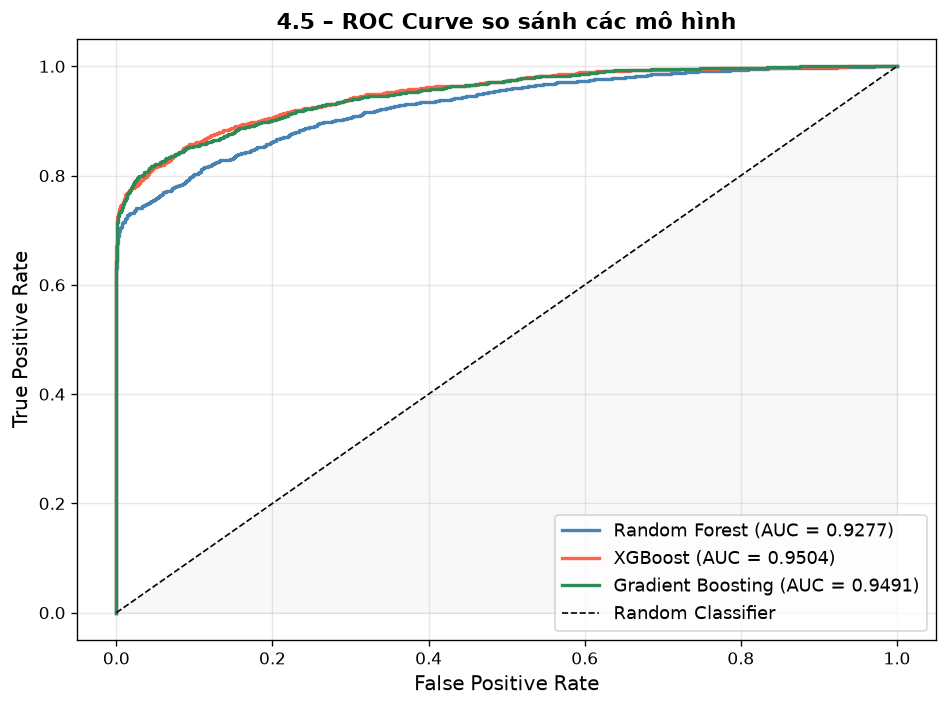

In [27]:
# 4.5 ROC CURVE
plt.figure(figsize=(8, 6))
colors_roc = ['steelblue', 'tomato', 'seagreen']

for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC = {v['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('4.5 – ROC Curve so sánh các mô hình', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('model_03_roc_curve.png', dpi=150)
plt.show()

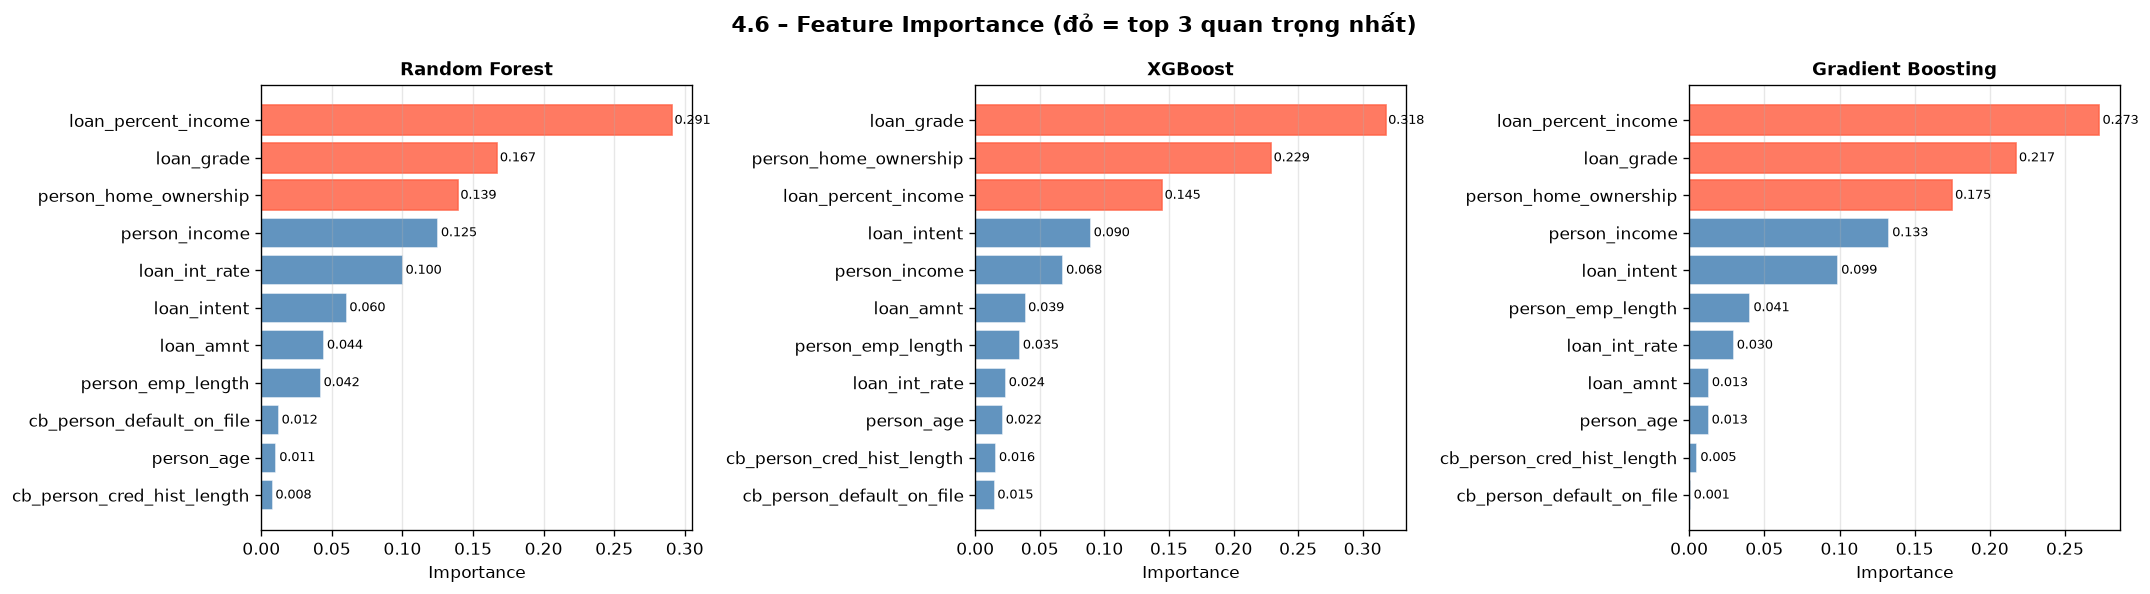

In [28]:
# 4.6 FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feature_names = X.columns.tolist()

for ax, (name, v) in zip(axes, results.items()):
    model = v['model']
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    bars = ax.barh(feat_imp.index, feat_imp.values,
                   color='steelblue', edgecolor='white', alpha=0.85)
    # Tô màu top 3
    top3_idx = feat_imp.nlargest(3).index
    for bar, label in zip(bars, feat_imp.index):
        if label in top3_idx:
            bar.set_color('tomato')
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)

    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('4.6 – Feature Importance (đỏ = top 3 quan trọng nhất)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_04_feature_importance.png', dpi=150)
plt.show()

In [29]:
# PHẦN 5: TỐI ƯU HÓA MÔ HÌNH (HYPERPARAMETER TUNING)

from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.metrics import make_scorer
import time

# 5.1 CROSS-VALIDATION TRƯỚC KHI TUNING
print(" Cross-Validation (5-fold) TRƯỚC khi tuning:\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(roc_auc_score)

baseline_models = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':           XGBClassifier(n_estimators=100, random_state=42,
                                       eval_metric='logloss', verbosity=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cv_scores_before = {}
for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring=scorer, n_jobs=-1)
    cv_scores_before[name] = scores
    print(f"  {name:<22} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")


 Cross-Validation (5-fold) TRƯỚC khi tuning:

  Random Forest          ROC-AUC: 0.8455 ± 0.0066
  XGBoost                ROC-AUC: 0.8646 ± 0.0032
  Gradient Boosting      ROC-AUC: 0.8419 ± 0.0045


In [30]:
# 5.2 RANDOMIZED SEARCH – RANDOM FOREST
print("\n Tuning Random Forest (RandomizedSearchCV)...")

rf_param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
rf_random.fit(X_train_scaled, y_train)
print(f"   Thời gian: {time.time()-start:.1f}s")
print(f"   Best params: {rf_random.best_params_}")
print(f"   Best ROC-AUC (CV): {rf_random.best_score_:.4f}")


 Tuning Random Forest (RandomizedSearchCV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
   Thời gian: 405.3s
   Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'bootstrap': False}
   Best ROC-AUC (CV): 0.9324


In [31]:
# 5.3 RANDOMIZED SEARCH – XGBOOST
print("\n Tuning XGBoost (RandomizedSearchCV)...")

xgb_param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 5, 6, 8, 10],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.2, 0.5],
    'reg_alpha':         [0, 0.01, 0.1, 1],
    'reg_lambda':        [1, 1.5, 2, 5]
}
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
xgb_random.fit(X_train_scaled, y_train)
print(f"  Thời gian: {time.time()-start:.1f}s")
print(f"   Best params: {xgb_random.best_params_}")
print(f"   Best ROC-AUC (CV): {xgb_random.best_score_:.4f}")


 Tuning XGBoost (RandomizedSearchCV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Thời gian: 53.0s
   Best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.9}
   Best ROC-AUC (CV): 0.9503


In [32]:
# 5.4 RandomizedSearchCV – GRADIENT BOOSTING
print("\n Tuning Gradient Boosting ...")

gb_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 7],
    'learning_rate':     [0.05, 0.1, 0.2],
    'subsample':         [0.7, 0.8, 0.9],
    'min_samples_split': [2, 5]
}

gb_random = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=20,          # chỉ thử 20 tổ hợp thay vì 162
    cv=3,               # 3-fold thay vì 5-fold cho nhanh
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
gb_random.fit(X_train_scaled, y_train)
print(f"   Thời gian: {time.time()-start:.1f}s")
print(f"   Best params: {gb_random.best_params_}")
print(f"   Best ROC-AUC (CV): {gb_random.best_score_:.4f}")


 Tuning Gradient Boosting ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
   Thời gian: 105.9s
   Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.05}
   Best ROC-AUC (CV): 0.9470


In [33]:
# 5.5 ĐÁNH GIÁ MÔ HÌNH SAU TUNING
print("\n Đánh giá trên tập TEST sau tuning:\n")

tuned_models = {
    'Random Forest':     rf_random.best_estimator_,
    'XGBoost':           xgb_random.best_estimator_,
    'Gradient Boosting': gb_random.best_estimator_
}

tuned_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    tuned_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob),
        'y_pred':   y_pred,
        'y_prob':   y_prob
    }
    print(f"  {name:<22} Accuracy: {tuned_results[name]['accuracy']:.4f} "
          f"| F1: {tuned_results[name]['f1']:.4f} "
          f"| ROC-AUC: {tuned_results[name]['roc_auc']:.4f}")


 Đánh giá trên tập TEST sau tuning:

  Random Forest          Accuracy: 0.9377 | F1: 0.8352 | ROC-AUC: 0.9403
  XGBoost                Accuracy: 0.9378 | F1: 0.8369 | ROC-AUC: 0.9530
  Gradient Boosting      Accuracy: 0.9410 | F1: 0.8458 | ROC-AUC: 0.9502



  {'Mô hình':<22} {'ROC-AUC Trước':>15} {'ROC-AUC Sau':>13} {'Cải thiện':>11}
  ---------------------------------------------------------------
  Random Forest                   0.9277        0.9403 ↑   0.0126
  XGBoost                         0.9504        0.9530 ↑   0.0025
  Gradient Boosting               0.9491        0.9502 ↑   0.0011


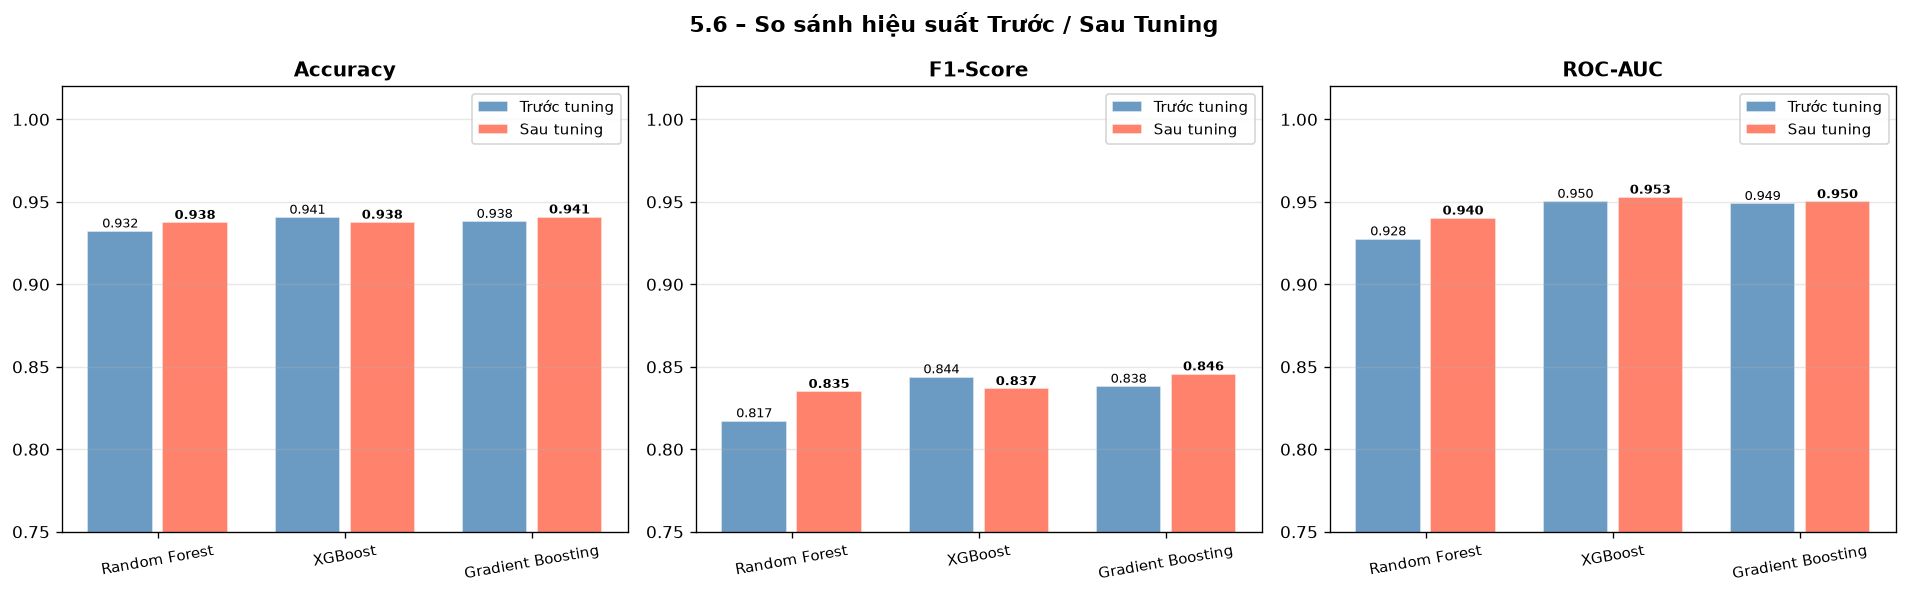

In [34]:
# 5.6 SO SÁNH TRƯỚC / SAU TUNING
print("\n  {'Mô hình':<22} {'ROC-AUC Trước':>15} {'ROC-AUC Sau':>13} {'Cải thiện':>11}")
print("  " + "-" * 63)
for name in results.keys():
    before = results[name]['roc_auc']
    after  = tuned_results[name]['roc_auc']
    delta  = after - before
    arrow  = "↑" if delta > 0 else "↓"
    print(f"  {name:<22} {before:>15.4f} {after:>13.4f} "
          f"{arrow} {abs(delta):>8.4f}")

# Biểu đồ so sánh trước/sau
metrics     = ['accuracy', 'f1', 'roc_auc']
labels      = ['Accuracy', 'F1-Score', 'ROC-AUC']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, label in zip(axes, metrics, labels):
    before_vals = [results[n][metric] for n in model_names]
    after_vals  = [tuned_results[n][metric] for n in model_names]
    x = np.arange(len(model_names))

    bars1 = ax.bar(x - 0.2, before_vals, width=0.35,
                   label='Trước tuning', color='steelblue',
                   edgecolor='white', alpha=0.8)
    bars2 = ax.bar(x + 0.2, after_vals, width=0.35,
                   label='Sau tuning', color='tomato',
                   edgecolor='white', alpha=0.8)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10, fontsize=9)
    ax.set_ylim(0.75, 1.02)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('5.6 – So sánh hiệu suất Trước / Sau Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_01_before_after.png', dpi=150)
plt.show()

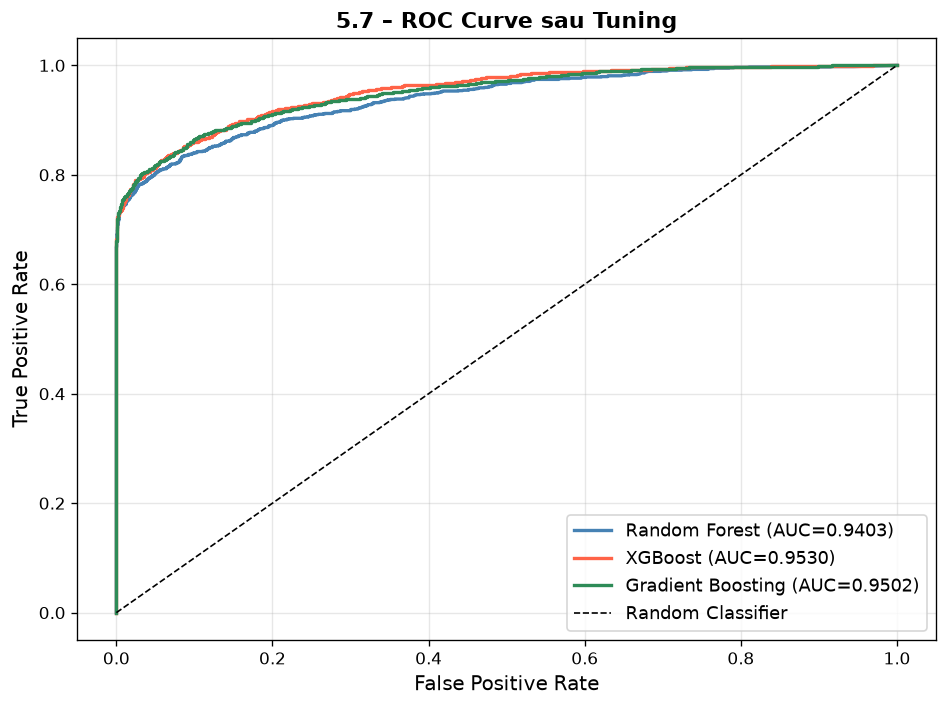

In [35]:
# 5.7 ROC CURVE SAU TUNING
plt.figure(figsize=(8, 6))
colors_roc = ['steelblue', 'tomato', 'seagreen']

for (name, v), color in zip(tuned_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC={v['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('5.7 – ROC Curve sau Tuning', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tuning_02_roc_after.png', dpi=150)
plt.show()

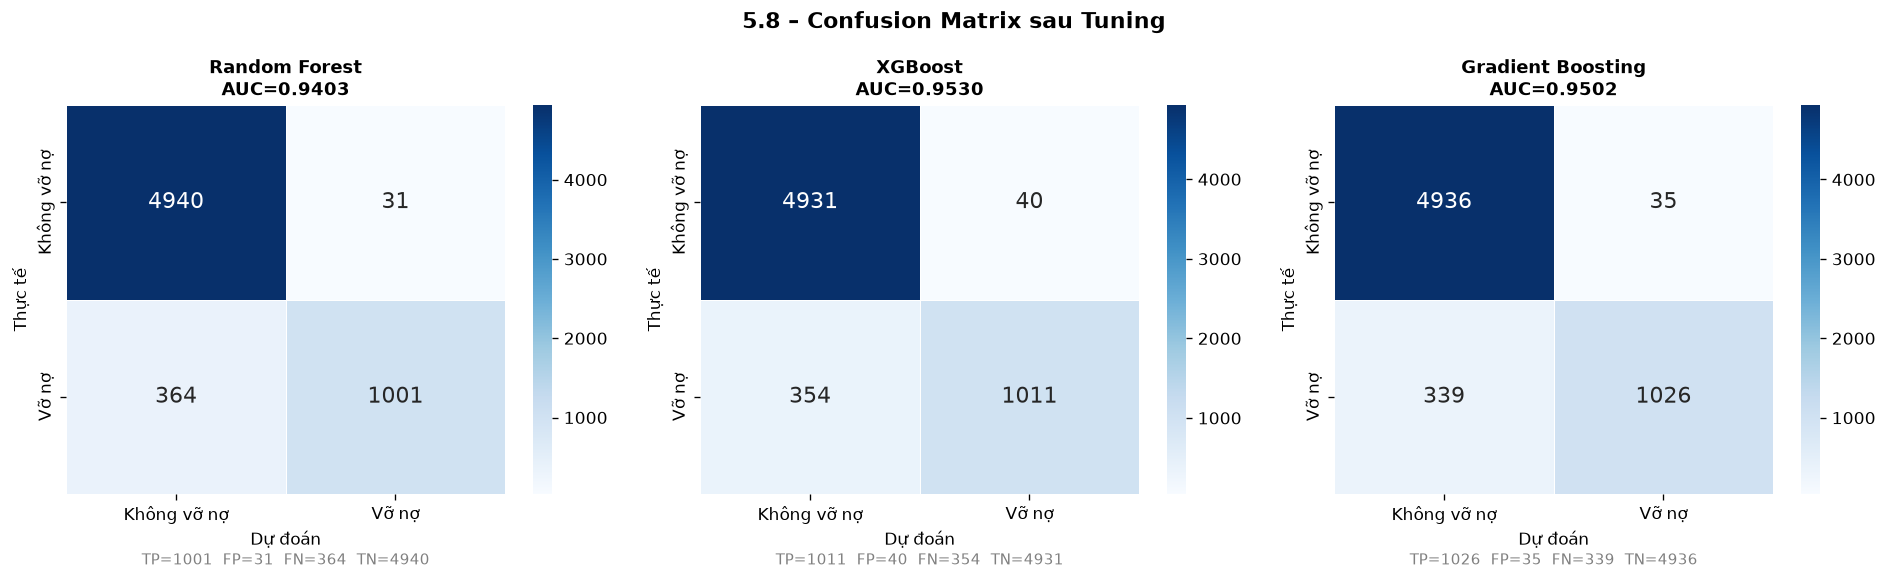

In [36]:
# 5.8 CONFUSION MATRIX SAU TUNING
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, v) in zip(axes, tuned_results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Không vỡ nợ', 'Vỡ nợ'],
                yticklabels=['Không vỡ nợ', 'Vỡ nợ'],
                annot_kws={'size': 13})
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nAUC={v["roc_auc"]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
    ax.text(0.5, -0.18,
            f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
            ha='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.suptitle('5.8 – Confusion Matrix sau Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_03_confusion_after.png', dpi=150)
plt.show()


In [37]:
# 5.9 LƯU MÔ HÌNH TỐT NHẤT
import joblib

best_name  = max(tuned_results, key=lambda n: tuned_results[n]['roc_auc'])
best_model = tuned_models[best_name]

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print(f"""
           KẾT QUẢ TỐI ƯU HÓA MÔ HÌNH
  Phương pháp tuning:
    Random Forest     → RandomizedSearchCV (30 iter, 5-fold)
    XGBoost           → RandomizedSearchCV (30 iter, 5-fold)
    Gradient Boosting → RandomizedSearchCV (20 iter, 3-fold)

   Mô hình tốt nhất: {best_name:<38}║
   ROC-AUC tốt nhất: {tuned_results[best_name]['roc_auc']:.4f}

   Đã lưu:
    best_model.pkl    → mô hình tốt nhất
    scaler.pkl        → bộ chuẩn hóa dữ liệu
    feature_names.pkl → danh sách đặc trưng
""")


           KẾT QUẢ TỐI ƯU HÓA MÔ HÌNH
  Phương pháp tuning:
    Random Forest     → RandomizedSearchCV (30 iter, 5-fold)
    XGBoost           → RandomizedSearchCV (30 iter, 5-fold)
    Gradient Boosting → RandomizedSearchCV (20 iter, 3-fold)

   Mô hình tốt nhất: XGBoost                               ║
   ROC-AUC tốt nhất: 0.9530

   Đã lưu:
    best_model.pkl    → mô hình tốt nhất
    scaler.pkl        → bộ chuẩn hóa dữ liệu
    feature_names.pkl → danh sách đặc trưng

